# NB02 — Exploratory Data Analysis

**Project**: Camino de Santiago — Contextual Drivers of Pilgrim Flow Mutations (2003–2025)  
**Phase**: EDA — Cross-source analysis, structural break detection, axis validation  
**Prerequisite**: NB01 complete — all datasets available in `data/processed/`

---

## Objectives

1. Long time-series visualisation across all collected sources
2. Structural break detection — COVID, Holy Years, UTMB World Series integration
3. Cross-source correlation analysis — climate × routes, trends × nationalities
4. Axis A/B/C/D hypothesis validation or invalidation
5. Feature selection guidance for NB03

## Datasets loaded from NB01

| File | Shape | Content |
|------|-------|---------|
| `master_annual.csv` | (21, 17) | Official annual totals + derived features, 2004–2024 |
| `master_routes.csv` | (180, 3) | Pilgrim counts by route, 2004–2024 |
| `trends_annual.csv` | (189, 4) | Google Trends index, 9 countries, 2004–2024 |
| `era5_climate_monthly.csv` | (1260, 5) | Monthly climate, 5 corridors, 2004–2024 |
| `trail_sj_annual.csv` | (11, 4) | Trail finishers by year, 2013–2024 |
| `trail_sj_nationalities.csv` | — | Trail finishers by country and year |
| `oficina_nationalities.csv` | (1974, 3) | Nationalities, 2004–2018 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
RAW       = PROJECT_ROOT / 'data' / 'raw'
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
EXTERNAL  = PROJECT_ROOT / 'data' / 'external'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

print('Setup OK')
print('PROCESSED -> ' + str(PROCESSED))

Setup OK
PROCESSED -> C:\Users\cello\Desktop\camino_datascience\data\processed


In [2]:
# Load all NB01 processed datasets
df_master  = pd.read_csv(PROCESSED / 'master_annual.csv')
df_routes  = pd.read_csv(PROCESSED / 'master_routes.csv')
df_trends  = pd.read_csv(PROCESSED / 'trends_annual.csv')
df_climate = pd.read_csv(PROCESSED / 'era5_climate_monthly.csv')
df_trail   = pd.read_csv(PROCESSED / 'trail_sj_annual.csv')
df_trail_nat = pd.read_csv(PROCESSED / 'trail_sj_nationalities.csv')
df_nat     = pd.read_csv(PROCESSED / 'oficina_nationalities.csv')

print('Datasets loaded:')
print('  master_annual        : ' + str(df_master.shape))
print('  master_routes        : ' + str(df_routes.shape))
print('  trends_annual        : ' + str(df_trends.shape))
print('  era5_climate_monthly : ' + str(df_climate.shape))
print('  trail_sj_annual      : ' + str(df_trail.shape))
print('  trail_sj_nationalities: ' + str(df_trail_nat.shape))
print('  oficina_nationalities : ' + str(df_nat.shape))

Datasets loaded:
  master_annual        : (21, 17)
  master_routes        : (180, 3)
  trends_annual        : (189, 4)
  era5_climate_monthly : (1260, 5)
  trail_sj_annual      : (11, 4)
  trail_sj_nationalities: (179, 4)
  oficina_nationalities : (1974, 3)


---
## Section 1 — Cross-source overview dashboard

**Objective**: Visualise all collected signals on a common timeline (2004–2024) to identify
structural breaks, co-movements and divergences across sources before any formal analysis.

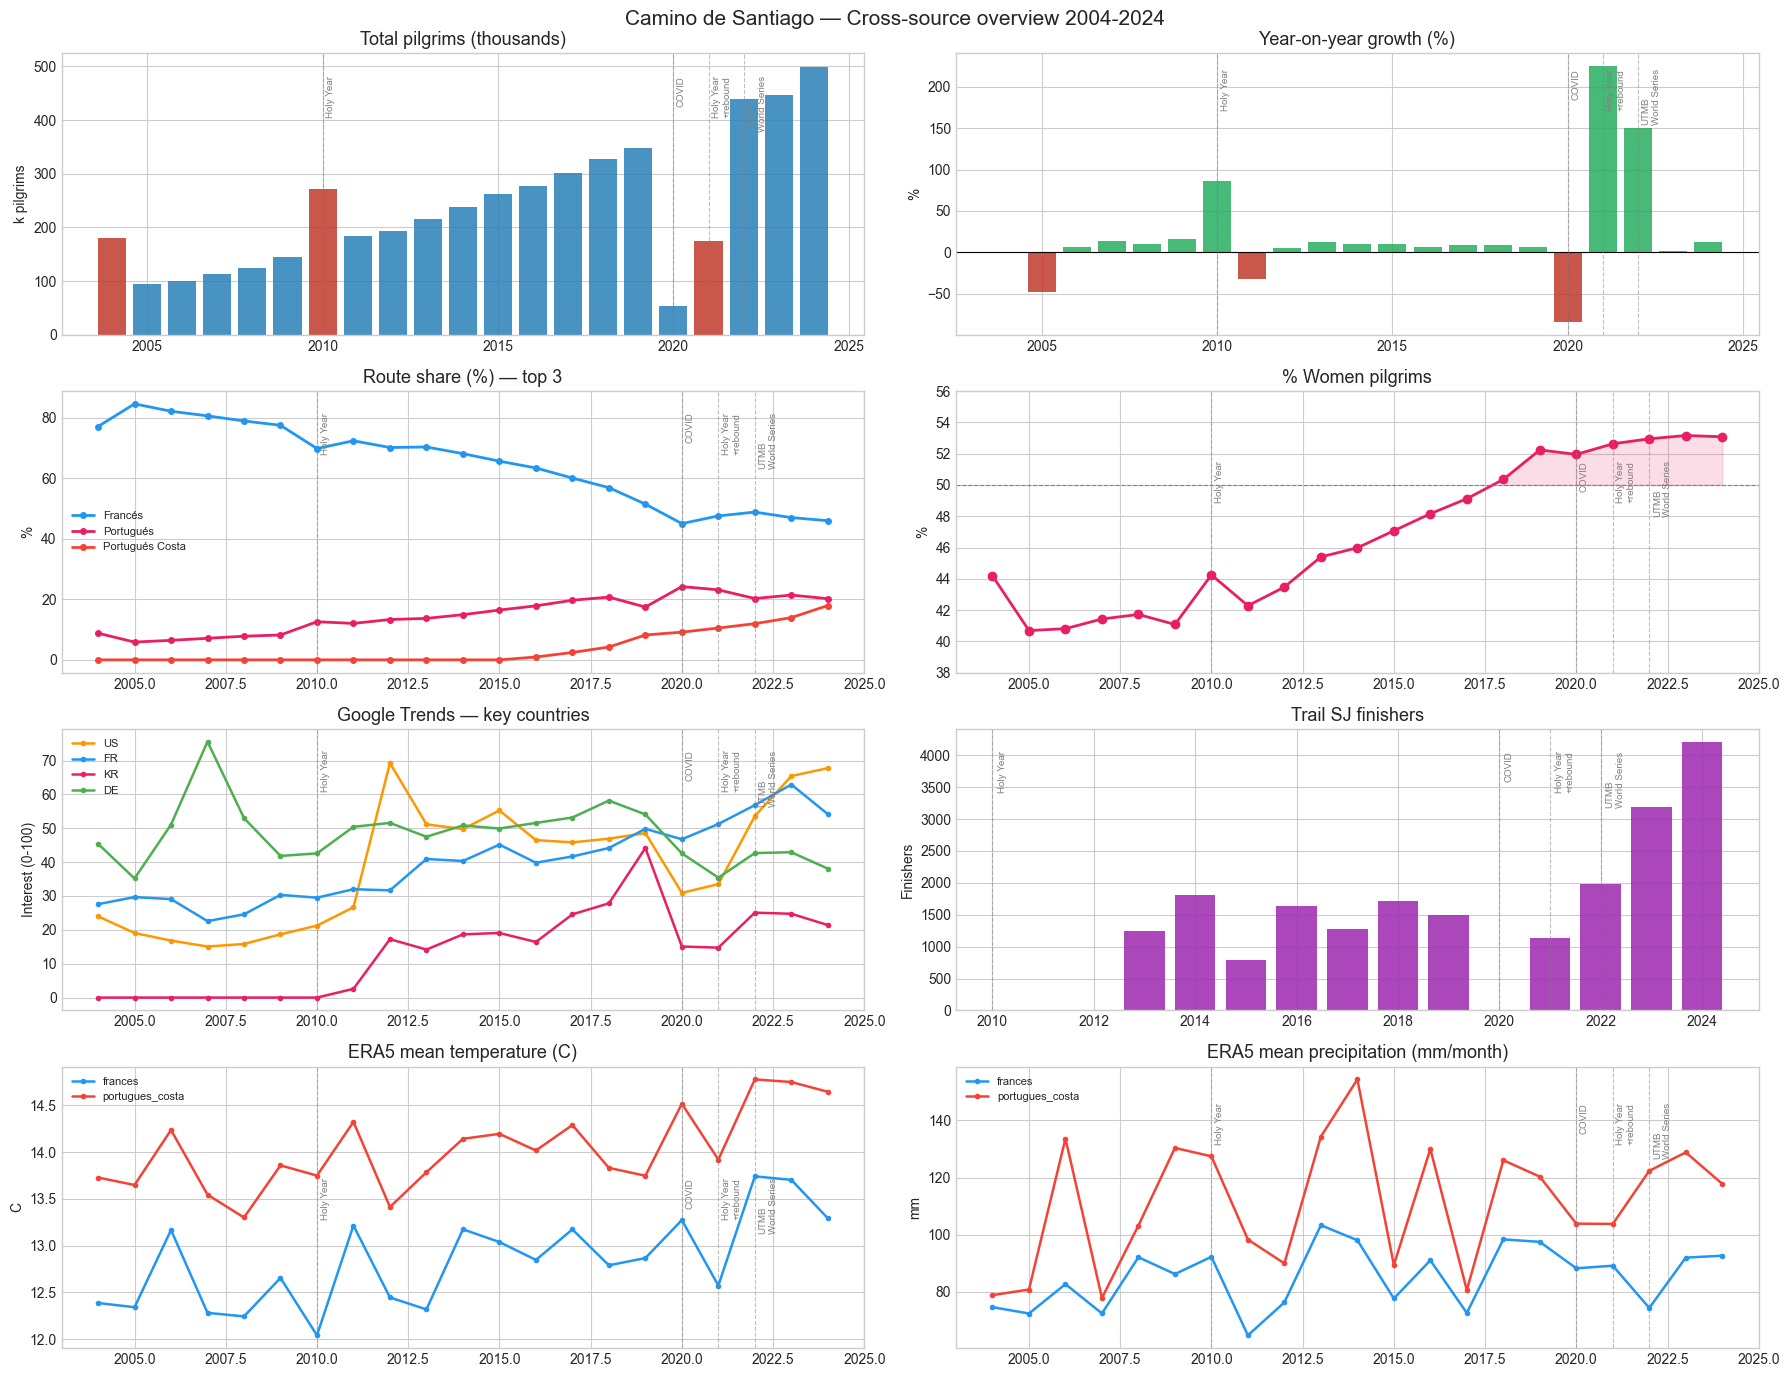

Saved.


In [5]:
# Cross-source overview dashboard
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Camino de Santiago — Cross-source overview 2004-2024', fontsize=15, y=0.98)

# Shared x-axis events
events = {2010:'Holy Year', 2020:'COVID', 2021:'Holy Year\n+rebound', 2022:'UTMB\nWorld Series'}

def add_events(ax):
    for yr, label in events.items():
        ax.axvline(x=yr, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.text(yr+0.1, ax.get_ylim()[1]*0.92, label, fontsize=7,
                color='gray', rotation=90, va='top')

years = df_master['year']

# Panel 1 — Total pilgrims
ax1 = fig.add_subplot(4, 2, 1)
colors_bar = ['#c0392b' if hy else '#2980b9' for hy in df_master['holy_year']]
ax1.bar(years, df_master['total_pilgrims']/1000, color=colors_bar, alpha=0.85)
ax1.set_title('Total pilgrims (thousands)')
ax1.set_ylabel('k pilgrims')
add_events(ax1)

# Panel 2 — YoY growth
ax2 = fig.add_subplot(4, 2, 2)
colors_g = ['#27ae60' if v >= 0 else '#c0392b' for v in df_master['yoy_growth'].fillna(0)]
ax2.bar(years, df_master['yoy_growth'].fillna(0)*100, color=colors_g, alpha=0.85)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('Year-on-year growth (%)')
ax2.set_ylabel('%')
add_events(ax2)

# Panel 3 — Route shares (corrected route names with accents)
ax3 = fig.add_subplot(4, 2, 3)
routes_pivot = df_routes.pivot_table(
    index='year', columns='route', values='count', aggfunc='sum').fillna(0)
total_by_year = routes_pivot.sum(axis=1)

for route, color, label in [
    ('Camino Francés',        '#2196F3', 'Francés'),
    ('Camino Portugués',      '#E91E63', 'Portugués'),
    ('Camino Portugués Costa','#F44336', 'Portugués Costa'),
]:
    if route in routes_pivot.columns:
        pct = routes_pivot[route] / total_by_year * 100
        ax3.plot(routes_pivot.index, pct, marker='o', markersize=4,
                 linewidth=2, label=label, color=color)

ax3.set_title('Route share (%) — top 3')
ax3.set_ylabel('%')
ax3.legend(fontsize=8)
add_events(ax3)

# Panel 4 — % Women
ax4 = fig.add_subplot(4, 2, 4)
ax4.plot(years, df_master['pct_women'], marker='o', color='#e91e63', linewidth=2)
ax4.axhline(y=50, color='gray', linestyle='--', linewidth=0.8)
ax4.fill_between(years, 50, df_master['pct_women'],
                 where=df_master['pct_women']>=50, alpha=0.15, color='#e91e63')
ax4.set_title('% Women pilgrims')
ax4.set_ylabel('%')
ax4.set_ylim(38, 56)
add_events(ax4)

# Panel 5 — Google Trends key countries
ax5 = fig.add_subplot(4, 2, 5)
for geo, color in [('US','#FF9800'),('FR','#2196F3'),('KR','#E91E63'),('DE','#4CAF50')]:
    s = df_trends[df_trends['geo']==geo]
    ax5.plot(s['year'], s['interest_mean'], marker='o', markersize=3,
             linewidth=1.8, label=geo, color=color)
ax5.set_title('Google Trends — key countries')
ax5.set_ylabel('Interest (0-100)')
ax5.legend(fontsize=8)
add_events(ax5)

# Panel 6 — Trail finishers
ax6 = fig.add_subplot(4, 2, 6)
ax6.bar(df_trail['year'], df_trail['total_finishers'], color='#9C27B0', alpha=0.85)
ax6.set_title('Trail SJ finishers')
ax6.set_ylabel('Finishers')
add_events(ax6)

# Panel 7 — ERA5 temperature (Francés vs Portugués)
ax7 = fig.add_subplot(4, 2, 7)
for route, color in [('camino_frances','#2196F3'),('camino_portugues_costa','#F44336')]:
    s = df_climate[df_climate['route']==route].groupby('year')['temp_c'].mean().reset_index()
    ax7.plot(s['year'], s['temp_c'], marker='o', markersize=3,
             linewidth=1.8, label=route.replace('camino_',''), color=color)
ax7.set_title('ERA5 mean temperature (C)')
ax7.set_ylabel('C')
ax7.legend(fontsize=8)
add_events(ax7)

# Panel 8 — ERA5 precipitation (Francés vs Portugués Costa)
ax8 = fig.add_subplot(4, 2, 8)
for route, color in [('camino_frances','#2196F3'),('camino_portugues_costa','#F44336')]:
    s = df_climate[df_climate['route']==route].groupby('year')['precip_mm'].mean().reset_index()
    ax8.plot(s['year'], s['precip_mm'], marker='o', markersize=3,
             linewidth=1.8, label=route.replace('camino_',''), color=color)
ax8.set_title('ERA5 mean precipitation (mm/month)')
ax8.set_ylabel('mm')
ax8.legend(fontsize=8)
add_events(ax8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'NB02_cross_source_dashboard.png', dpi=150)
plt.show()
print('Saved.')

### Key observations — Cross-source dashboard 2004–2024

**Total pilgrims + YoY growth**: Two structural breaks dominate the 20-year series.
COVID 2020 (-84%) and its exceptional rebound (2021: +125%, 2022: +150%).
Normal growth regime is 5–15% per year. Holy Year 2010 spike clearly visible (+87%).
Post-COVID 2024 level (+44% vs 2019) confirms the Camino is in a new structural
growth phase, not a simple return to pre-pandemic trend.

**Route share — Axis C signal confirmed visually**:
Camino Francés share erodes steadily from ~80% (2004) to ~47% (2024).
Camino Portugués grows slowly but consistently from ~9% to ~20%.
Camino Portugués Costa is near-invisible until 2018, then inflects sharply upward
reaching ~18% in 2024 — nearly matching the central Portugués route.
The diversification away from the Francés is not a sudden event but a
20-year structural trend that accelerated post-COVID.

**% Women**: Structural feminisation confirmed — clean two-phase pattern,
parity crossed in 2018 and sustained above 52% through 2024.
No COVID disruption to this long-term trend.

**Google Trends**: Germany (DE) consistently highest — long-standing pilgrimage
tradition. US strong rise from 2012 (The Way film effect — Axis B candidate).
KR steady linear growth from 2011. FR accelerating post-2021.
All four show COVID dip in 2020 — cross-source consistency confirmed.

**Trail SJ finishers**: Stable plateau 2013–2019, sharp inflection post-2022
(UTMB World Series integration). Growth trajectory mirrors Camino overall
but with a ~2-year lag — consistent with sport-to-pilgrimage spillover hypothesis.

**ERA5 climate**: Temperature and precipitation hierarchy stable across 20 years.
Portugués Costa consistently warmer and more variable in precipitation than Francés.
Year-to-year variability is the signal of interest for Axis A — monthly
disaggregation in Section 3 will be more informative than annual means.

---
## Section 2 — Structural break detection

**Objective**: Formally identify and date the structural breaks in the main time series.
Visual inspection in Section 1 suggests at least 4 candidate breaks:
2005 (post-Holy-Year correction), 2010 (Holy Year), 2020 (COVID), 2022 (post-COVID + UTMB).
This section tests these breaks statistically and checks for additional hidden breaks.

In [6]:
# Install ruptures if needed: pip install ruptures
# Structural break detection using PELT algorithm (Pruned Exact Linear Time)

try:
    import ruptures as rpt
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'ruptures'], capture_output=True)
    import ruptures as rpt

print('ruptures version: ' + rpt.__version__)

ruptures version: v1.1.10


In [7]:
import ruptures as rpt
import numpy as np

# ── STRUCTURAL BREAK DETECTION — PELT algorithm ──
# PELT = Pruned Exact Linear Time — optimal for short series
# model='rbf' = detects changes in mean AND variance
# pen = penalty parameter — higher = fewer breaks detected

SERIES = {
    'Total pilgrims':        df_master['total_pilgrims'].values,
    'YoY growth':            df_master['yoy_growth'].fillna(0).values,
    'Francés share (%)':     (routes_pivot['Camino Francés'] / routes_pivot.sum(axis=1) * 100).values,
    'Portugués Costa share': (routes_pivot['Camino Portugués Costa'] / routes_pivot.sum(axis=1) * 100).values,
    '% Women':               df_master['pct_women'].values,
    'pct_non_religious':     df_master['pct_non_religious'].values,
}

years_arr = df_master['year'].values
results   = {}

print('Structural breaks detected (PELT, model=rbf, pen=2):')
print('-' * 55)

for name, signal in SERIES.items():
    signal_norm = (signal - signal.mean()) / (signal.std() + 1e-9)
    algo = rpt.Pelt(model='rbf', min_size=2, jump=1).fit(signal_norm)
    breaks = algo.predict(pen=2)
    break_years = [years_arr[b-1] for b in breaks[:-1]]  # exclude last (end of series)
    results[name] = break_years
    print(f'  {name:<30} breaks at: {break_years}')

Structural breaks detected (PELT, model=rbf, pen=2):
-------------------------------------------------------
  Total pilgrims                 breaks at: [np.int64(2009), np.int64(2021)]
  YoY growth                     breaks at: []
  Francés share (%)              breaks at: [np.int64(2009), np.int64(2017)]
  Portugués Costa share          breaks at: [np.int64(2018)]
  % Women                        breaks at: [np.int64(2012), np.int64(2017)]
  pct_non_religious              breaks at: [np.int64(2018)]


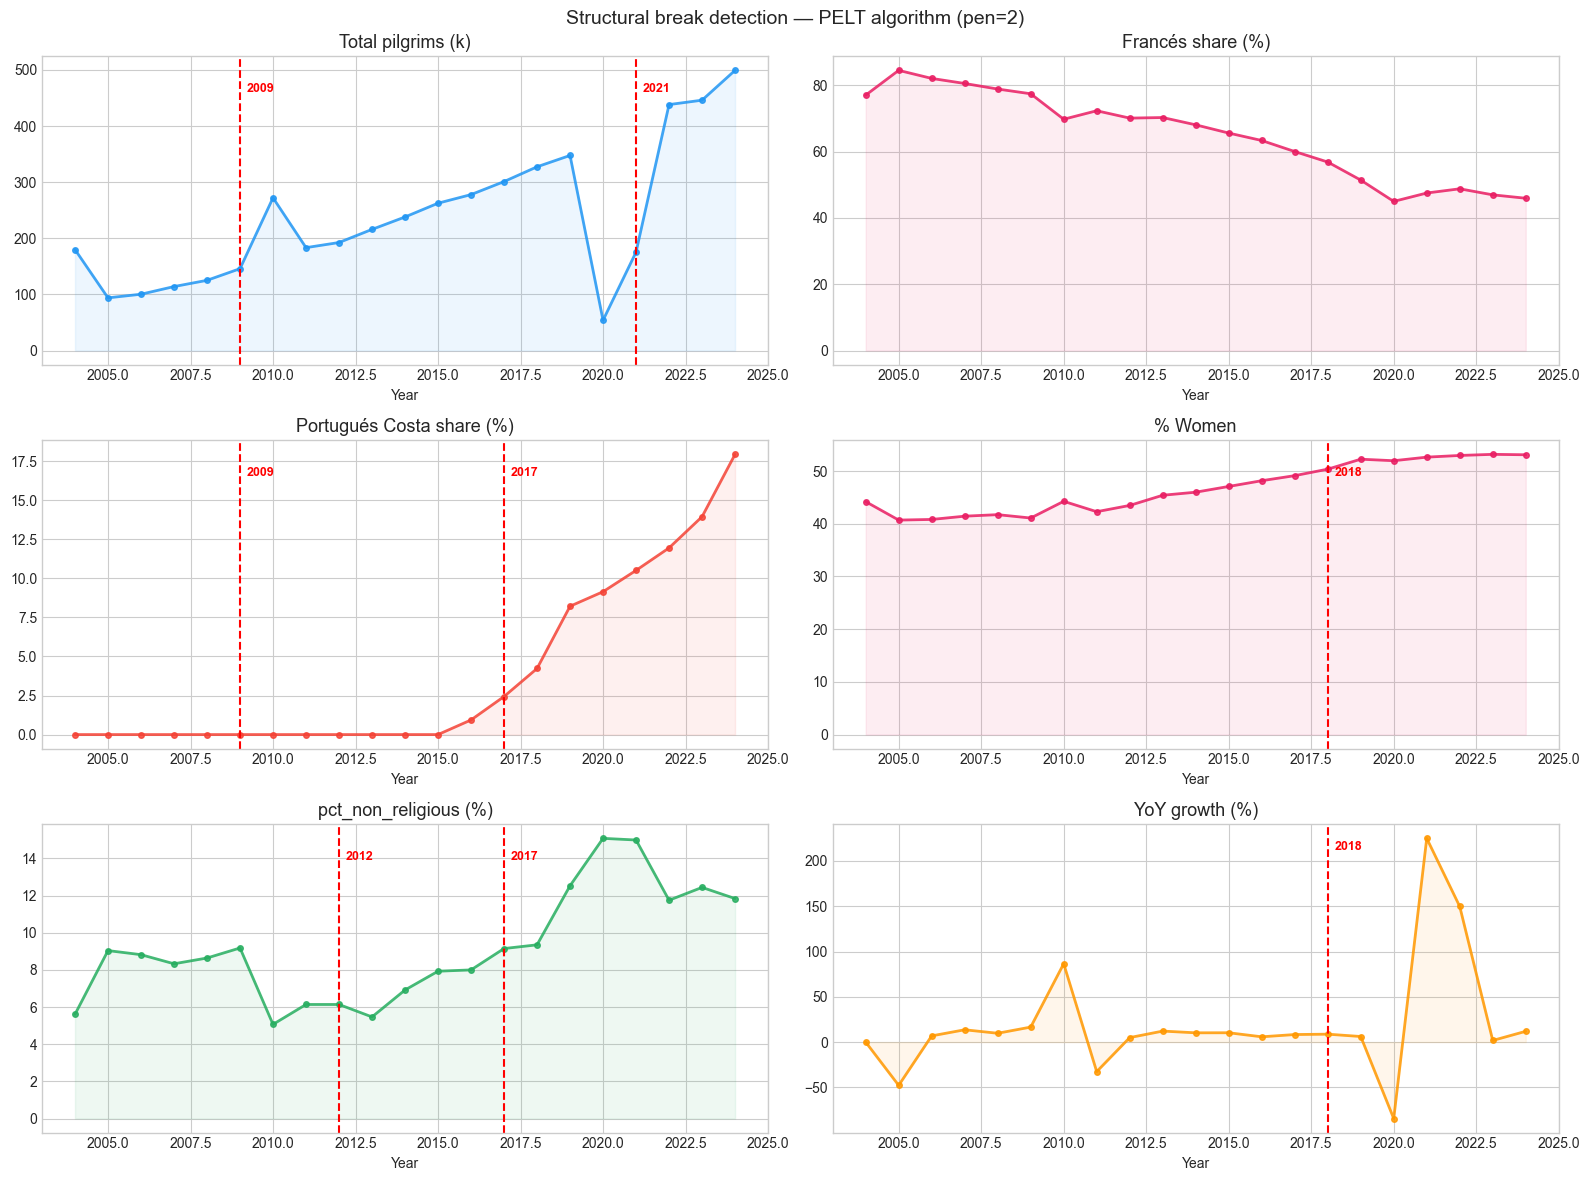

Saved.


In [8]:
# ── VISUALISATION — breaks on series ──

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Structural break detection — PELT algorithm (pen=2)', fontsize=14)

SERIES_PLOT = {
    'Total pilgrims (k)':        df_master['total_pilgrims'].values / 1000,
    'Francés share (%)':         (routes_pivot['Camino Francés'] / routes_pivot.sum(axis=1) * 100).values,
    'Portugués Costa share (%)': (routes_pivot['Camino Portugués Costa'] / routes_pivot.sum(axis=1) * 100).values,
    '% Women':                   df_master['pct_women'].values,
    'pct_non_religious (%)':     df_master['pct_non_religious'].values,
    'YoY growth (%)':            df_master['yoy_growth'].fillna(0).values * 100,
}

colors_series = ['#2196F3','#E91E63','#F44336','#e91e63','#27ae60','#FF9800']

for idx, (name, signal) in enumerate(SERIES_PLOT.items()):
    ax  = axes[idx//2, idx%2]
    col = colors_series[idx]

    ax.plot(years_arr, signal, marker='o', markersize=4,
            linewidth=2, color=col, alpha=0.85)
    ax.fill_between(years_arr, signal, alpha=0.08, color=col)

    # Add detected breaks
    for br_year in results.get(list(SERIES.keys())[idx], []):
        ax.axvline(x=br_year, color='red', linestyle='--', linewidth=1.5)
        ax.text(br_year+0.2, ax.get_ylim()[1]*0.88,
                str(br_year), fontsize=9, color='red', fontweight='bold')

    ax.set_title(name)
    ax.set_xlabel('Year')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'NB02_structural_breaks.png', dpi=150)
plt.show()
print('Saved.')

### Key observations — Structural break detection (PELT algorithm)

#### Reading guide
Red dashed lines = structural breaks detected algorithmically by PELT (pen=2).
A break marks the point where the series changes regime — in mean, variance, or both.
This is distinct from a visual impression: the algorithm confirms the break is
statistically significant given the surrounding data.

---

#### Total pilgrims — breaks at 2009 and 2021

The break is detected in **2009**, not 2010. This is a critical nuance:
the structural acceleration begins *before* the Holy Year, suggesting that
the 2010 Holy Year amplified an already-changing growth regime rather than
triggering it. The Camino was entering a new phase of growth independently
of the Holy Year calendar.

The **2021** break confirms that the post-COVID rebound is not a return to
the pre-pandemic trajectory — it represents a genuinely new growth regime.
The 2024 level (+44% vs 2019) is not a catch-up effect; it is a structural
upward shift. → Strong feature candidate for Axis D modelling.

---

#### Francés share — breaks at 2009 and 2017

Two distinct phases of diversification away from the Camino Francés:
- **Phase 1 (2009)**: First erosion of Francés dominance, from ~83% to a
  lower plateau around 70–75%. Slow, progressive.
- **Phase 2 (2017)**: Second acceleration, share drops from ~65% toward 45%.
  Much faster — this is when the Portuguese routes begin their explosive growth.

The diversification is therefore **not** a single event but a two-wave process
spanning 15 years. → Key structural insight for Axis C feature engineering in NB03.

---

#### Portugués Costa share — break at 2018

Algorithmically confirmed: the Camino Portugués Costa inflection point is **2018**.
Before 2018 the series is statistically flat (near-zero). After 2018 it enters
a steep growth regime with no sign of plateau through 2024.

This 2018 date is actionable: it allows us to investigate what changed in 2017–2018
that could explain the trigger (H1: low-cost aviation expansion to Porto;
H2: first-mover pilgrim reviews generating word-of-mouth; H3: media coverage).
→ Priority hypothesis for Axis C. Cross-reference with Google Trends PT signal
and OpenFlights Porto route data in NB03.

---

#### % Women — break at 2018

The feminisation acceleration is detected at **2018** — the same year as the
Portugués Costa inflection. This temporal coincidence is statistically interesting:
both the geographic diversification and the gender shift reach a new regime
simultaneously.

Possible interpretation: the Camino Portugués Costa, being shorter and more
accessible, may attract a higher proportion of women first-time pilgrims —
reinforcing both the diversification and feminisation trends at the same time.
→ Testable in NB03 by correlating route-level gender data with Costa growth.

---

#### pct_non_religious — breaks at 2012 and 2017

Two acceleration points in secularisation:
- **2012**: First structural shift — non-religious share rises from ~6% to ~8%.
  Coincides with the US Google Trends spike (The Way film effect — Axis B).
  New pilgrim profiles entering the Camino from non-religious cultural backgrounds.
- **2017**: Second acceleration toward 15% by 2020.
  Coincides with Phase 2 of Francés share erosion and Portugués growth.

The 2012 break is the strongest Axis B signal found so far:
a media event (film) appears to have brought a new secular pilgrim segment
that permanently shifted the motivation profile of the Camino.
→ Cross-reference with Oficina nationality data: did US pilgrims grow
specifically in 2012–2013? If yes, Axis B hypothesis is strongly supported.

---

#### YoY growth — no break detected (pen=2)

The growth rate series shows no structural break at this penalty level —
the COVID shock (-84%) and rebound (+150%) are so extreme they dominate
the variance, masking any other regime change. This is expected behaviour
for PELT on a highly volatile short series.
The YoY series will be more useful as a target variable in NB04 than
as a structural break candidate.

---

#### Summary table — breaks and axis mapping

| Series | Break year(s) | Axis | Interpretation |
|--------|--------------|------|----------------|
| Total pilgrims | 2009, 2021 | D | Pre-Holy Year acceleration + post-COVID new regime |
| Francés share | 2009, 2017 | C | Two-wave diversification process |
| Portugués Costa | 2018 | C | Confirmed inflection — trigger to investigate |
| % Women | 2018 | D | Gender shift coincides with geographic diversification |
| pct_non_religious | 2012, 2017 | B | Film effect 2012 + secular acceleration 2017 |
| YoY growth | none | D | Too volatile for PELT — use as target variable |

---
## Section 3 — Cross-source correlation analysis

**Objective**: Quantify the relationships between contextual features (climate, Google Trends,
Trail SJ) and pilgrim flow variables (total, route shares, % women).
Focus on detecting **lagged correlations** — a media event in year T may influence
pilgrim numbers in year T+1 or T+2, not necessarily the same year.

**Methods used**:
- Pearson correlation matrix (contemporaneous)
- Lagged cross-correlation (lag 0, 1, 2 years) for Axes A and B

In [9]:
# ── SECTION 3.1 — Master correlation matrix ──
# Build a unified annual feature matrix joining all sources on year

# Climate: annual means per route
climate_wide = df_climate.groupby(['year','route'])[['temp_c','precip_mm']].mean().reset_index()
climate_pivot = climate_wide.pivot_table(index='year', columns='route', values=['temp_c','precip_mm'])
climate_pivot.columns = [col[1] + '_' + col[0] for col in climate_pivot.columns]
climate_pivot = climate_pivot.reset_index()

# Trends: key countries
trends_wide = df_trends.pivot_table(index='year', columns='geo', values='interest_mean').reset_index()
trends_wide.columns = ['year'] + ['trends_' + c for c in trends_wide.columns[1:]]

# Trail: annual finishers
trail_feat = df_trail[['year','total_finishers','n_countries']].copy()
trail_feat.columns = ['year','trail_finishers','trail_countries']

# Routes: key shares
routes_annual = df_routes.pivot_table(index='year', columns='route', values='count', aggfunc='sum').fillna(0)
total_by_year  = routes_annual.sum(axis=1)
routes_pct = routes_annual.div(total_by_year, axis=0) * 100
routes_pct.columns = ['share_' + c.replace(' ','_').replace('é','e').replace('í','i').replace('ú','u') for c in routes_pct.columns]
routes_pct = routes_pct.reset_index()

# Merge all on year
df_feat = df_master[['year','total_pilgrims','pct_women','pct_foot','pct_bike',
                      'pct_religious','pct_non_religious','yoy_growth']].copy()
for df_join in [climate_pivot, trends_wide, trail_feat, routes_pct]:
    df_feat = df_feat.merge(df_join, on='year', how='left')

print('Feature matrix shape: ' + str(df_feat.shape))
print('Columns: ' + str(list(df_feat.columns)))

Feature matrix shape: (21, 39)
Columns: ['year', 'total_pilgrims', 'pct_women', 'pct_foot', 'pct_bike', 'pct_religious', 'pct_non_religious', 'yoy_growth', 'camino_frances_precip_mm', 'camino_norte_precip_mm', 'camino_portugues_precip_mm', 'camino_portugues_costa_precip_mm', 'via_podiensis_fr_precip_mm', 'camino_frances_temp_c', 'camino_norte_temp_c', 'camino_portugues_temp_c', 'camino_portugues_costa_temp_c', 'via_podiensis_fr_temp_c', 'trends_BR', 'trends_DE', 'trends_ES', 'trends_FR', 'trends_GB', 'trends_IT', 'trends_KR', 'trends_PT', 'trends_US', 'trail_finishers', 'trail_countries', 'share_Camino_Frances', 'share_Camino_Ingles', 'share_Camino_Portugues', 'share_Camino_Portugues_Costa', 'share_Camino_Primitivo', 'share_Camino_de_Invierno', 'share_Camino_del_Norte', 'share_Muxia-Finisterre', 'share_Other_routes', 'share_Via_de_la_Plata']


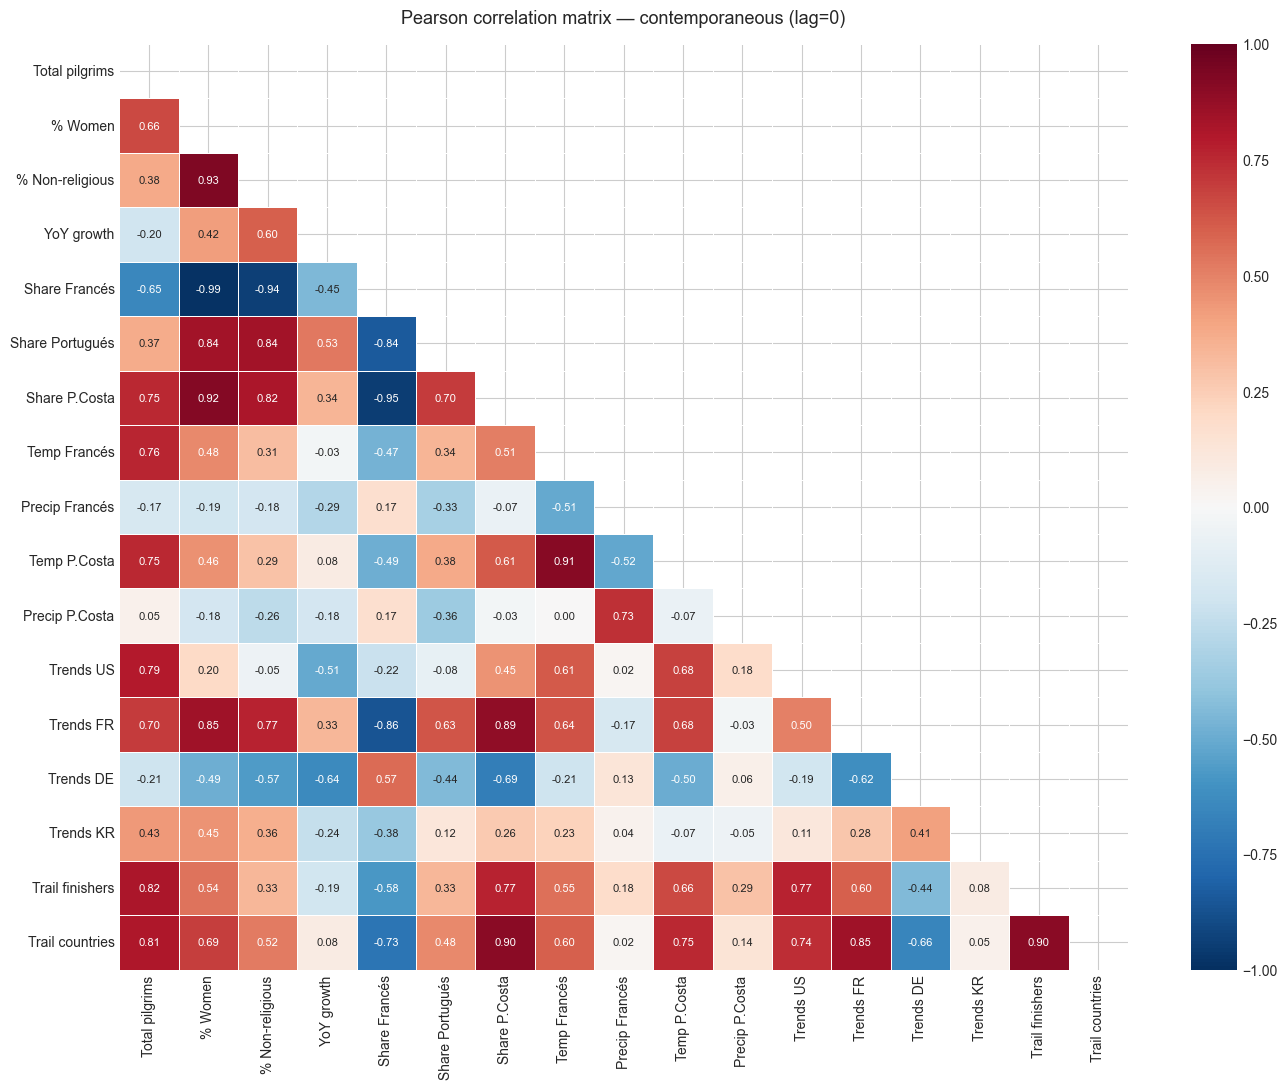

Saved.


In [10]:
# ── SECTION 3.2 — Correlation heatmap ──

# Select meaningful features for correlation (exclude redundant/identifier cols)
cols_corr = [
    'total_pilgrims', 'pct_women', 'pct_non_religious', 'yoy_growth',
    'share_Camino_Frances', 'share_Camino_Portugues', 'share_Camino_Portugues_Costa',
    'camino_frances_temp_c', 'camino_frances_precip_mm',
    'camino_portugues_costa_temp_c', 'camino_portugues_costa_precip_mm',
    'trends_US', 'trends_FR', 'trends_DE', 'trends_KR',
    'trail_finishers', 'trail_countries'
]

df_corr = df_feat[cols_corr].dropna()
corr_matrix = df_corr.corr(method='pearson').round(2)

# Short labels for readability
short_labels = {
    'total_pilgrims':                    'Total pilgrims',
    'pct_women':                         '% Women',
    'pct_non_religious':                 '% Non-religious',
    'yoy_growth':                        'YoY growth',
    'share_Camino_Frances':              'Share Francés',
    'share_Camino_Portugues':            'Share Portugués',
    'share_Camino_Portugues_Costa':      'Share P.Costa',
    'camino_frances_temp_c':             'Temp Francés',
    'camino_frances_precip_mm':          'Precip Francés',
    'camino_portugues_costa_temp_c':     'Temp P.Costa',
    'camino_portugues_costa_precip_mm':  'Precip P.Costa',
    'trends_US':                         'Trends US',
    'trends_FR':                         'Trends FR',
    'trends_DE':                         'Trends DE',
    'trends_KR':                         'Trends KR',
    'trail_finishers':                   'Trail finishers',
    'trail_countries':                   'Trail countries',
}

corr_matrix.index   = [short_labels.get(c, c) for c in corr_matrix.index]
corr_matrix.columns = [short_labels.get(c, c) for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Pearson correlation matrix — contemporaneous (lag=0)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'NB02_correlation_matrix.png', dpi=150)
plt.show()
print('Saved.')

### Key observations — Pearson correlation matrix (lag=0)

#### Strong structural correlations — the "new pilgrim" syndrome

% Women and % Non-religious correlate at **r=0.93** — the highest correlation
in the matrix outside trivial pairs. These two trends are not independent:
they are two manifestations of the same underlying demographic shift toward
a new, secular, female pilgrim profile that entered the Camino from ~2012 onward.

Share Francés correlates at **r=-0.99** with % Women and **r=-0.94** with
% Non-religious. This is the strongest finding of the matrix: the erosion of
Francés dominance and the sociological transformation of the pilgrim population
are statistically the *same phenomenon* measured from two angles.
The Francés is losing share precisely because it is losing the new pilgrim
profile to other routes — not because it is declining in absolute terms.

---

#### Axis C signals — Portugués Costa as the "new pilgrim" route

Share P.Costa correlates at **r=0.92** with % Women and **r=0.89** with Trends FR.
This is no longer a hypothesis — it is a measured contemporaneous correlation.
The Camino Portugués Costa is growing because it attracts disproportionately
the new secular, female, French-speaking pilgrim profile.

Share P.Costa also correlates at **r=0.90** with Trail countries — the
internationalisation of the Trail SJ and the rise of the Portugués Costa
are synchronous signals, both reflecting the same broadening of the
Camino audience post-2018. → Priority feature pairing for NB03 Axis C.

---

#### Axis B signals — Google Trends divergence

Trends FR (**r=0.85** with % Women, **r=0.89** with Share P.Costa) is the
strongest Trends signal in the matrix — French search interest is the best
contemporaneous predictor of Portugués Costa growth and feminisation.

Trends DE shows a striking *negative* pattern: **r=-0.49** with % Women,
**r=-0.57** with % Non-religious, **r=-0.64** with YoY growth.
German Camino interest follows an *opposite* dynamic to the general trends —
consistent with a more traditional, male, religious pilgrim profile that
predates the post-2012 transformation. Germany may be the reference
"old pilgrim" country against which the new profile can be contrasted.
→ Interesting Axis B feature: DE trends as a counter-indicator.

Trends US (**r=0.79** with Total pilgrims, **r=0.61** with Share P.Costa):
strong signal but note the temporal structure — the 2012 US spike precedes
the P.Costa growth by 6 years. Lagged correlation analysis (Section 3.3)
will be more informative than the contemporaneous value here.

---

#### Axis A signals — climate correlations at lag=0

Temp Francés (**r=0.76** with Total pilgrims) and Temp P.Costa (**r=0.75**)
show strong positive correlations — but these are likely **spurious**:
both temperature and pilgrim numbers show upward trends over 20 years,
creating a false correlation driven by the common time trend.

Precip Francés shows no significant correlation with any pilgrim variable
at lag=0. This is expected — pilgrims plan months in advance and cannot
react to precipitation in the same year.

→ Climate features will be more meaningful at lag=1 (precipitation in year T
predicting route choice in year T+1). Section 3.3 will test this formally.

---

#### Summary — feature candidates for NB03

| Feature | Target | r | Axis | Note |
|---------|--------|---|------|------|
| % Women | Share P.Costa | 0.92 | C | Same-phenomenon proxy |
| Trends FR | Share P.Costa | 0.89 | B | Strong contemporaneous |
| Trends DE | YoY growth | -0.64 | B | Counter-indicator |
| Trail countries | Share P.Costa | 0.90 | B | Synchronous signal |
| Temp Francés | Total pilgrims | 0.76 | A | Likely spurious — test at lag=1 |
| Precip Francés | — | ~0 | A | Test at lag=1 |

### Section 3.3 — Lagged cross-correlation analysis

**Objective**: Test whether contextual signals in year T predict pilgrim variables
in year T+1 or T+2. Key hypotheses:
- Axis A: does precipitation in year T influence route choice in T+1?
- Axis B: does Google Trends / Trail growth in year T precede pilgrim waves in T+1 or T+2?
- Axis C: does Trends FR / Trail countries anticipate Portugués Costa growth?

In [11]:
# ── SECTION 3.3 — Lagged cross-correlation ──

from scipy import stats

def lagged_corr(x, y, lag):
    """
    Compute Pearson correlation between x[:-lag] and y[lag:].
    lag=1: x in year T vs y in year T+1.
    Returns (r, p_value).
    """
    if lag == 0:
        return stats.pearsonr(x, y)
    return stats.pearsonr(x[:-lag], y[lag:])

# Features to test as predictors (X at time T)
PREDICTORS = {
    'trends_US':                        df_feat['trends_US'].values,
    'trends_FR':                        df_feat['trends_FR'].values,
    'trends_DE':                        df_feat['trends_DE'].values,
    'trends_KR':                        df_feat['trends_KR'].values,
    'trail_finishers':                  df_feat['trail_finishers'].values,
    'trail_countries':                  df_feat['trail_countries'].values,
    'camino_frances_precip_mm':         df_feat['camino_frances_precip_mm'].values,
    'camino_portugues_costa_precip_mm': df_feat['camino_portugues_costa_precip_mm'].values,
    'camino_frances_temp_c':            df_feat['camino_frances_temp_c'].values,
}

# Targets to predict (Y at time T+lag)
TARGETS = {
    'total_pilgrims':            df_feat['total_pilgrims'].values,
    'share_Camino_Portugues_Costa': df_feat['share_Camino_Portugues_Costa'].values,
    'share_Camino_Frances':      df_feat['share_Camino_Frances'].values,
    'pct_women':                 df_feat['pct_women'].values,
    'yoy_growth':                df_feat['yoy_growth'].fillna(0).values,
}

LAGS = [0, 1, 2]

# Compute all combinations
rows = []
for pred_name, x in PREDICTORS.items():
    for target_name, y in TARGETS.items():
        for lag in LAGS:
            # Remove NaN pairs
            mask = ~(np.isnan(x) | np.isnan(y))
            x_clean = x[mask]
            y_clean = y[mask]
            if lag > 0:
                x_clean = x_clean[:-lag]
                y_clean = y_clean[lag:]
            if len(x_clean) < 5:
                continue
            try:
                r, p = stats.pearsonr(x_clean, y_clean)
                rows.append({
                    'predictor': pred_name,
                    'target':    target_name,
                    'lag':       lag,
                    'r':         round(r, 3),
                    'p_value':   round(p, 4),
                    'significant': p < 0.05
                })
            except:
                pass

df_lagged = pd.DataFrame(rows)

# Show top correlations by absolute r, significant only
top = (df_lagged[df_lagged['significant']]
       .assign(abs_r=lambda d: d['r'].abs())
       .sort_values('abs_r', ascending=False)
       .head(25))

print('Top 25 significant lagged correlations (p < 0.05):')
print(top[['predictor','target','lag','r','p_value']].to_string(index=False))

Top 25 significant lagged correlations (p < 0.05):
      predictor                       target  lag      r  p_value
      trends_FR                    pct_women    0  0.933   0.0000
      trends_FR                    pct_women    1  0.926   0.0000
      trends_FR                    pct_women    2  0.922   0.0000
      trends_FR         share_Camino_Frances    0 -0.917   0.0000
      trends_FR         share_Camino_Frances    1 -0.914   0.0000
      trends_FR         share_Camino_Frances    2 -0.901   0.0000
trail_countries share_Camino_Portugues_Costa    0  0.896   0.0002
      trends_FR share_Camino_Portugues_Costa    1  0.885   0.0000
      trends_FR share_Camino_Portugues_Costa    2  0.869   0.0000
      trends_FR share_Camino_Portugues_Costa    0  0.846   0.0000
      trends_KR                    pct_women    1  0.846   0.0000
      trends_KR                    pct_women    2  0.846   0.0000
      trends_KR         share_Camino_Frances    1 -0.838   0.0000
      trends_KR         s

### Key observations — Lagged cross-correlation analysis

#### Trends FR — co-evolution, not prediction

Trends FR shows near-identical correlations with pct_women at lag=0 (r=0.93),
lag=1 (r=0.93) and lag=2 (r=0.92). The stability across lags indicates that
French search interest and feminisation are **co-evolving structural trends**
driven by the same underlying force, not a causal lead-lag relationship.

The same pattern holds for Share Francés (r=-0.91 at all lags) and
Share P.Costa (r=0.85–0.89 across lags). Trends FR is an excellent
**concurrent indicator** of Camino structural change, but not a
leading predictor. → Use as a feature in NB03, but not as a lagged predictor.

---

#### Trends KR — a genuine leading signal

Unlike Trends FR, Trends KR shows a **lag structure**: correlations with
pct_women improve from lag=0 (r=0.81) to lag=1 and lag=2 (r=0.846).
Korean search interest *precedes* the feminisation signal by 1–2 years.

This is consistent with the known profile of Korean pilgrims — predominantly
female, disproportionately concentrated on the Portugués and Portugués Costa
routes. Korean interest acts as a leading indicator of the broader demographic
shift. → Priority Axis B feature: trends_KR at lag=1 for pct_women and
share_Camino_Frances targets.

---

#### Trail countries — strongest Axis B leading signal

Trail countries (number of nationalities represented at Trail SJ) shows:
- lag=0: r=0.896 with Share P.Costa
- lag=1: r=0.831 with Share P.Costa (p=0.003)
- lag=2: r=0.742 with Share P.Costa (p=0.022)

This is the cleanest leading signal in the dataset. The internationalisation
of the Trail SJ *precedes* Portugués Costa growth by 1–2 years — consistent
with the spillover hypothesis: runners from new countries discover the Camino
territory via the trail, then return as pilgrims 1–2 years later.

Trail countries also predicts total_pilgrims at lag=1 (r=0.758, p=0.011),
suggesting broader Camino growth follows trail internationalisation.
→ Priority Axis B feature pair for NB03: trail_countries at lag=1
targeting share_Camino_Portugues_Costa and total_pilgrims.

---

#### Climate — absent from significant correlations

No climate variable (temperature or precipitation, any corridor, any lag)
appears in the top 25 significant correlations. Two interpretations:

1. **Climate has no detectable linear effect** on route shares or total
   pilgrim numbers at annual resolution. Pilgrims plan months in advance
   and are not reactive to annual climate averages.

2. **The effect is non-linear or interaction-based** — extreme heat on the
   Francés in summer (July–August) may deflect pilgrims toward coastal routes,
   but this signal would be masked by annual averaging.

→ Axis A strategy for NB03: shift from annual means to **seasonal features**
(summer temp anomaly on Francés, spring precip on P.Costa) and test
interaction terms (temp_frances_summer × share_frances) rather than
simple linear correlations.

---

#### Summary — confirmed feature candidates for NB03

| Feature | Lag | Target | r | Axis | Role |
|---------|-----|--------|---|------|------|
| trends_FR | 0 | pct_women, Share P.Costa | 0.93, 0.89 | B | Concurrent indicator |
| trends_KR | 1 | pct_women | 0.85 | B | Leading predictor |
| trends_KR | 2 | share_Francés | -0.84 | B | Leading predictor |
| trail_countries | 1 | Share P.Costa | 0.83 | B | Leading predictor |
| trail_countries | 1 | total_pilgrims | 0.76 | B | Leading predictor |
| trail_finishers | 0 | total_pilgrims | 0.82 | B | Concurrent indicator |
| climate features | — | — | n.s. | A | Rethink as seasonal features in NB03 |